In [3]:
import numpy as np  # モジュールNumpyをnpという名前でインポート
import matplotlib.pyplot as plt  # 図の出力に使用するモジュール
from scipy import stats  # 高度な統計分析を行うためのサブモジュール

In [4]:
# Ynの漸近分布である正規分布N(μ,σ^2)のパラメータμ
def mu(p):
    return 100 * p

# Ynの漸近分布である正規分布N(μ,σ^2)のパラメータσ
def sigma(n, p):
    return 100 * np.sqrt(p * (1-p) / n)

# 受験者数m，設問数n，各設問の得点率pを引数として
# Zn，Ynのm人分の結果を配列Z，Yに格納する
def genZY(m, n, p):
    Z = np.zeros(m)  # 配列Zを初期化
    Y = np.zeros(m)  # 配列Yを初期化
    mu_p = mu(p)  # 100p
    sigma_n_p = sigma(n, p)  # 100 * √(p(1-p)/n)
    n_times_p = n * p  # np
    sqrt_npq = np.sqrt(n * p * (1 - p))  # √(np(1-p))
    np.random.seed(1)  # 乱数のシード値を固定
    for i in range(m):
        # Be(p)に従うn個の乱数X1, X2, ..., Xnを生成
        X = np.random.binomial(1, p, n)
        Z[i] = (sum(X) - n_times_p) / sqrt_npq
        Y[i] = mu_p + sigma_n_p * Z[i]
    return Z, Y

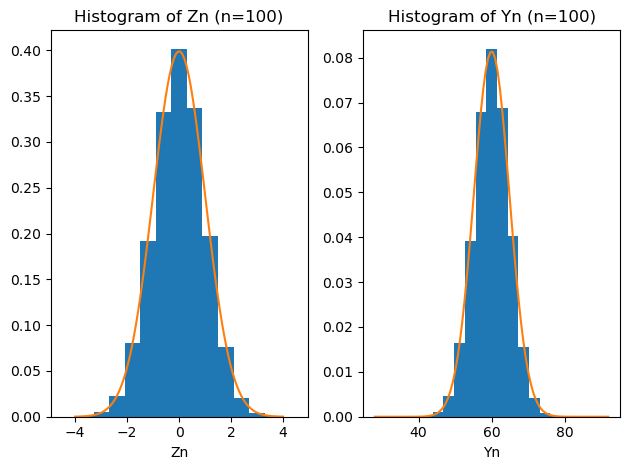

In [5]:
# 受験者数m，設問数n，各設問の得点率pを指定
m = 250000
n = 100
p = 0.6
# Zn，Ynのm人分の結果を配列Z，Yに格納する
Z, Y = genZY(m, n, p)

plt.subplot(1, 2, 1)  # 1行2列のうち1列目
plt.title('Histogram of Zn (n=%d)' % n)
plt.xlabel('Zn')
plt.hist(Z, bins = 15, density = True) # Znのヒストグラム
x1 = np.linspace(-4, 4, 100)
# N(0,1)の密度関数を重ねて表示
plt.plot(x1, stats.norm.pdf(x1, loc = 0, scale = 1))

plt.subplot(1, 2, 2)  # 1行2列のうち2列目
plt.title('Histogram of Yn (n=%d)' % n)
plt.xlabel('Yn')
plt.hist(Y, bins = 15, density = True) # Ynのヒストグラム
x2 = np.linspace(min(Y) - 10, max(Y) + 10, 100)
# N(μ,σ^2)の密度関数を重ねて表示
plt.plot(x2, stats.norm.pdf(x2, loc = mu(p), scale = sigma(n, p)))
plt.tight_layout()  # グラフの配置を調節
plt.show()